In [ ]:
pip install scikit-rf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.3/631.3 kB 3.1 MB/s eta 0:00:00


In [ ]:
import argparse
import numpy as np
import matplotlib.pyplot as plt

# ---- S2P loader (robust option) ----
# Uses scikit-rf to parse S2P properly.
import skrf as rf

import torch
import torch.nn as nn
import torch.optim as optim

import os, glob
from torch.utils.data import Dataset, DataLoader

In [ ]:
def load_s21_mag_db_from_s2p(path: str):
    ntwk = rf.Network(path)

    f_hz = ntwk.f  # shape (M,)
    s = ntwk.s     # shape (M, 2, 2), complex

    # S21 is row=1, col=0 in 0-based indexing (port2 <- port1)
    s21 = s[:, 1, 0]
    mag = np.abs(s21)
    mag_db = 20.0 * np.log10(np.maximum(mag, 1e-12))

    return f_hz.astype(np.float64), mag_db.astype(np.float64)

In [ ]:
def resample_to_fixed_grid(f_hz: np.ndarray, y: np.ndarray, n_points: int):
    # Create uniform grid over existing range and interpolate
    f_min, f_max = float(f_hz.min()), float(f_hz.max())
    f_new = np.linspace(f_min, f_max, n_points)
    y_new = np.interp(f_new, f_hz, y)
    return f_new, y_new

In [ ]:
def standardize_1d(y: np.ndarray):
    mu = float(y.mean())
    sigma = float(y.std() + 1e-12)
    y_std = (y - mu) / sigma
    return y_std, mu, sigma

In [ ]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, latent_channels=16):
        super().__init__()
        # Input: (B, C=1, N)

        # Encoder
        self.enc = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),  # N -> N/2

            nn.Conv1d(8, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),  # N -> N/4

            nn.Conv1d(16, latent_channels, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # N -> N/8
        )

        # Pooling head for fixed-length features: (B, C, L) -> (B, C)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Decoder (mirror)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),  # N/8 -> N/4
            nn.Conv1d(latent_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode="nearest"),  # N/4 -> N/2
            nn.Conv1d(16, 8, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode="nearest"),  # N/2 -> N
            nn.Conv1d(8, 1, kernel_size=9, padding=4),
            # No activation: reconstruction in standardized space can be any real number
        )

    def encode(self, x, return_map: bool = False):
        """
        Returns:
          - latent map z with shape (B, latent_channels, L) if return_map=True
          - pooled feature vector feat with shape (B, latent_channels) otherwise
        """
        z = self.enc(x)  # (B, C, L)
        if return_map:
            return z
        feat = self.pool(z).squeeze(-1)  # (B, C, 1) -> (B, C)
        return feat

    def forward(self, x):
        z = self.enc(x)
        y = self.dec(z)
        return y

In [ ]:
def prepare_dataset(s2p_files, n_points=1024):
    signals = []

    for file in s2p_files:
        try:
            freq, mag = load_s21_mag_db_from_s2p(file)
            freq, mag = resample_to_fixed_grid(freq, mag, n_points)
            mag, _, _ = standardize_1d(mag)
            signals.append(mag)
        except:
            continue

    signals = np.array(signals)  # (N_samples, 1024)
    return torch.tensor(signals).float()

In [ ]:
def add_gaussian_noise(x, noise_std=0.1):
    noise = torch.randn_like(x) * noise_std
    return x + noise

In [ ]:
def add_masking_noise(x, mask_prob=0.1):
    mask = (torch.rand_like(x) > mask_prob).float()
    return x * mask

In [ ]:
def add_combined_noise(x):
    x = x + 0.05 * torch.randn_like(x)      # Gaussian
    mask = (torch.rand_like(x) > 0.1).float()
    x = x * mask                           # masking
    return x

In [ ]:
def train_model(
    s2p_files,
    checkpoint_dir,
    noise,
    num_epochs=100,
    lr=1e-3,
    batch_size=16,
    noise_std=0.1,
    plot_loss=True
):
    import os
    import matplotlib.pyplot as plt
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader

    # Prepare dataset
    data = prepare_dataset(s2p_files)
    dataset = torch.utils.data.TensorDataset(data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Model
    model = Conv1DAutoencoder()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()

    if noise == 'gaussian':
        save_dir = os.path.join(checkpoint_dir, 'gaussian')
    elif noise == 'mask':
        save_dir = os.path.join(checkpoint_dir, 'mask')
    elif noise == 'combined':
        save_dir = os.path.join(checkpoint_dir, 'combined')
    else:
        raise ValueError("noise must be one of: gaussian, mask, combined")

    os.makedirs(save_dir, exist_ok=True)

    training_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for (batch,) in dataloader:
            batch = batch.unsqueeze(1)  # (B, 1, 1024)

            # Corrupt input
            if noise == 'gaussian':
                noisy_batch = add_gaussian_noise(batch, noise_std=noise_std)
            elif noise == 'mask':
                noisy_batch = add_masking_noise(batch, mask_prob=0.1)
            elif noise == 'combined':
                noisy_batch = add_combined_noise(batch)

            optimizer.zero_grad()

            # Reconstruct clean input from noisy input
            output = model(noisy_batch)
            loss = criterion(output, batch)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        training_losses.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f}")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'noise_type': noise,
                'noise_std': noise_std,
            }, os.path.join(save_dir, f'checkpoint_epoch_{epoch+1}.pt'))

    if plot_loss:
        plt.figure(figsize=(10, 5))
        plt.plot(
            range(1, num_epochs + 1),
            training_losses,
            marker='o',
            label=f'{noise} denoising loss'
        )
        plt.xlabel("Epoch")
        plt.ylabel("Reconstruction MSE Loss")
        plt.title(f"Denoising Autoencoder Training Loss ({noise})")
        plt.grid(True)
        plt.legend()
        plt.show()

    return model, training_losses

In [ ]:
def train_model(
    s2p_files,
    checkpoint_dir,
    noise,
    num_epochs=100,
    lr=1e-3,
    batch_size=16,
    noise_std=0.1
):


    # Prepare dataset
    data = prepare_dataset(s2p_files)
    dataset = torch.utils.data.TensorDataset(data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Model
    model = Conv1DAutoencoder()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()

    if noise == 'gaussian':
      gauss_checkpoint_dir = checkpoint_dir + 'gaussian/'
      os.makedirs(gauss_checkpoint_dir, exist_ok=True)
    elif noise == 'mask':
      mask_checkpoint_dir = checkpoint_dir + 'mask/'
      os.makedirs(mask_checkpoint_dir, exist_ok=True)
    elif noise == 'combined':
      combined_checkpoint_dir = checkpoint_dir + 'combined/'
      os.makedirs(combined_checkpoint_dir, exist_ok=True)


    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for (batch,) in dataloader:
            batch = batch.unsqueeze(1)  # (B, 1, 1024)

            # Denoising step: corrupt the input
            if noise == 'gaussian':
              noisy_batch = add_gaussian_noise(batch, noise_std=noise_std)
              checkpoint_dir = gauss_checkpoint_dir
            elif noise == 'mask':
              noisy_batch = add_masking_noise(batch, mask_prob=0.1)
              checkpoint_dir = mask_checkpoint_dir
            elif noise == 'combined':
              noisy_batch = add_combined_noise(batch)
              checkpoint_dir = combined_checkpoint_dir

            optimizer.zero_grad()
            output = model(noisy_batch)

            # Reconstruct the CLEAN input
            loss = criterion(output, batch)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)

        if epoch % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f}")

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'noise_std': noise_std,
            }, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pt'))

    return model

In [ ]:
def test_one_file(model, s2p_path, file, n_points=1024, device="cpu"):
    model = model.to(device)
    model.eval()

    # --- preprocess exactly like training ---
    freq, mag_db = load_s21_mag_db_from_s2p(s2p_path)
    freq_new, mag_db = resample_to_fixed_grid(freq, mag_db, n_points)
    mag_std, mu, sigma = standardize_1d(mag_db)

    x = torch.tensor(mag_std).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,N)

    with torch.no_grad():
        y = model(x)  # reconstruction in standardized space

    y = y.squeeze().cpu().numpy()          # (N,)
    x_np = x.squeeze().cpu().numpy()       # (N,)

    # MSE in standardized space (this matches training loss scale)
    mse_std = float(np.mean((y - x_np) ** 2))

    # Optional: convert back to dB scale for interpretability
    x_db = x_np * sigma + mu
    y_db = y * sigma + mu

    # --- plot ---
    plt.figure()
    plt.plot(freq_new, x_db, label="Original S21 (dB)")
    plt.plot(freq_new, y_db, label="Reconstructed S21 (dB)")
    plt.title(os.path.basename(s2p_path) + f" | MSE(std)={mse_std:.6f}"+f"|{file}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("S21 magnitude (dB)")
    plt.legend()
    plt.show()

    return mse_std, (freq_new, x_db, y_db)

In [ ]:
# # continue training later
# checkpoint = torch.load("checkpoint_epoch_21.pt")

# model = Conv1DAutoencoder()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)

# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# start_epoch = checkpoint['epoch'] + 1

In [ ]:
root_dir = '/content/drive/MyDrive/Data/MAS Volunteer Study March 2023'

print(f"Traversing directory: {root_dir}")

s2p_files = []
error_data = []
for dirpath, dirnames, filenames in os.walk(root_dir):
    if 'Beamer' in dirpath:
        continue
    for filename in filenames:
        file_path = os.path.join(dirpath, filename)
        if filename == "Air.s2p":
          continue
        else:
          s2p_files.append(file_path)


Traversing directory: /content/drive/MyDrive/Data/MAS Volunteer Study March 2023


Epoch [1/200] Loss: 0.851882
Epoch [2/200] Loss: 0.130919
Epoch [3/200] Loss: 0.048569
Epoch [4/200] Loss: 0.034902
Epoch [5/200] Loss: 0.028670
Epoch [6/200] Loss: 0.025621
Epoch [7/200] Loss: 0.023596
Epoch [8/200] Loss: 0.021270
Epoch [9/200] Loss: 0.019111
Epoch [10/200] Loss: 0.017937
Epoch [11/200] Loss: 0.016677
Epoch [12/200] Loss: 0.015516
Epoch [13/200] Loss: 0.014730
Epoch [14/200] Loss: 0.013767
Epoch [15/200] Loss: 0.012890
Epoch [16/200] Loss: 0.011635
Epoch [17/200] Loss: 0.010212
Epoch [18/200] Loss: 0.009366
Epoch [19/200] Loss: 0.008484
Epoch [20/200] Loss: 0.007952
Epoch [21/200] Loss: 0.007585
Epoch [22/200] Loss: 0.006628
Epoch [23/200] Loss: 0.006176
Epoch [24/200] Loss: 0.005862
Epoch [25/200] Loss: 0.005367
Epoch [26/200] Loss: 0.005340
Epoch [27/200] Loss: 0.005123
Epoch [28/200] Loss: 0.004762
Epoch [29/200] Loss: 0.004415
Epoch [30/200] Loss: 0.004138
Epoch [31/200] Loss: 0.004074
Epoch [32/200] Loss: 0.003974
Epoch [33/200] Loss: 0.003661
Epoch [34/200] Loss

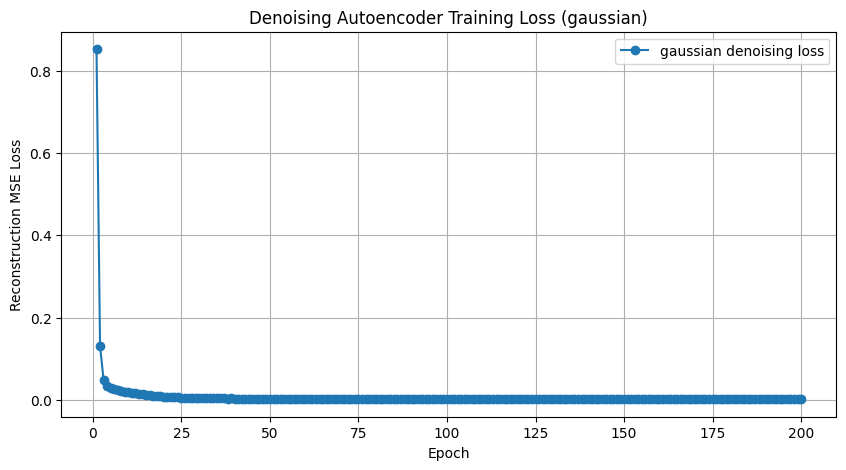

Epoch [1/200] Loss: 0.908531
Epoch [2/200] Loss: 0.456013
Epoch [3/200] Loss: 0.117223
Epoch [4/200] Loss: 0.051396
Epoch [5/200] Loss: 0.032434
Epoch [6/200] Loss: 0.025644
Epoch [7/200] Loss: 0.022381
Epoch [8/200] Loss: 0.020825
Epoch [9/200] Loss: 0.019282
Epoch [10/200] Loss: 0.018013
Epoch [11/200] Loss: 0.016669
Epoch [12/200] Loss: 0.015624
Epoch [13/200] Loss: 0.014382
Epoch [14/200] Loss: 0.013605
Epoch [15/200] Loss: 0.012537
Epoch [16/200] Loss: 0.012153
Epoch [17/200] Loss: 0.010889
Epoch [18/200] Loss: 0.010246
Epoch [19/200] Loss: 0.009621
Epoch [20/200] Loss: 0.009074
Epoch [21/200] Loss: 0.008248
Epoch [22/200] Loss: 0.007432
Epoch [23/200] Loss: 0.006900
Epoch [24/200] Loss: 0.006223
Epoch [25/200] Loss: 0.006896
Epoch [26/200] Loss: 0.005611
Epoch [27/200] Loss: 0.005424
Epoch [28/200] Loss: 0.005509
Epoch [29/200] Loss: 0.005209
Epoch [30/200] Loss: 0.004631
Epoch [31/200] Loss: 0.004349
Epoch [32/200] Loss: 0.004250
Epoch [33/200] Loss: 0.004001
Epoch [34/200] Loss

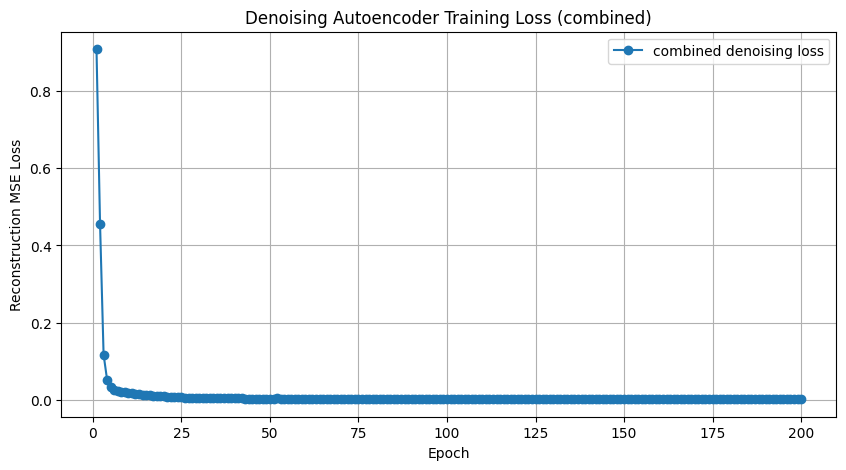

Epoch [1/200] Loss: 0.901495
Epoch [2/200] Loss: 0.530904
Epoch [3/200] Loss: 0.490889
Epoch [4/200] Loss: 0.471046
Epoch [5/200] Loss: 0.453199
Epoch [6/200] Loss: 0.436086
Epoch [7/200] Loss: 0.417900
Epoch [8/200] Loss: 0.401714
Epoch [9/200] Loss: 0.386418
Epoch [10/200] Loss: 0.371669
Epoch [11/200] Loss: 0.357818
Epoch [12/200] Loss: 0.347261
Epoch [13/200] Loss: 0.334737
Epoch [14/200] Loss: 0.324621
Epoch [15/200] Loss: 0.314256
Epoch [16/200] Loss: 0.304023
Epoch [17/200] Loss: 0.296004
Epoch [18/200] Loss: 0.286264
Epoch [19/200] Loss: 0.277995
Epoch [20/200] Loss: 0.269586
Epoch [21/200] Loss: 0.260632
Epoch [22/200] Loss: 0.254503
Epoch [23/200] Loss: 0.246823
Epoch [24/200] Loss: 0.239771
Epoch [25/200] Loss: 0.232176
Epoch [26/200] Loss: 0.225245
Epoch [27/200] Loss: 0.219312
Epoch [28/200] Loss: 0.212973
Epoch [29/200] Loss: 0.207399
Epoch [30/200] Loss: 0.200271
Epoch [31/200] Loss: 0.194488
Epoch [32/200] Loss: 0.188701
Epoch [33/200] Loss: 0.184369
Epoch [34/200] Loss

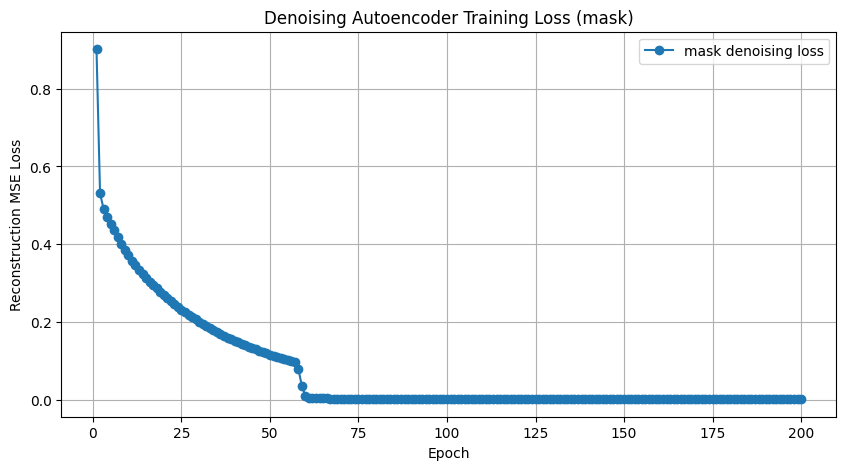

In [ ]:
checkpoints_dir = '/content/drive/MyDrive/Data/checkpoints/de_autoencoder/'

noise = ['gaussian','combined','mask']
for noise in noise:
  model = train_model(s2p_files,checkpoints_dir,noise,200)

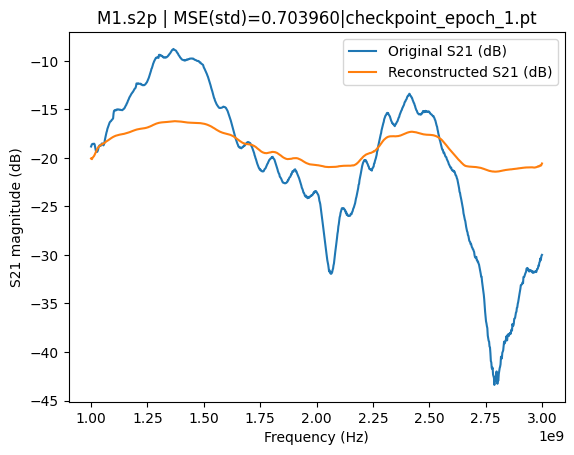

Test MSE (standardized space): 0.7039597034454346


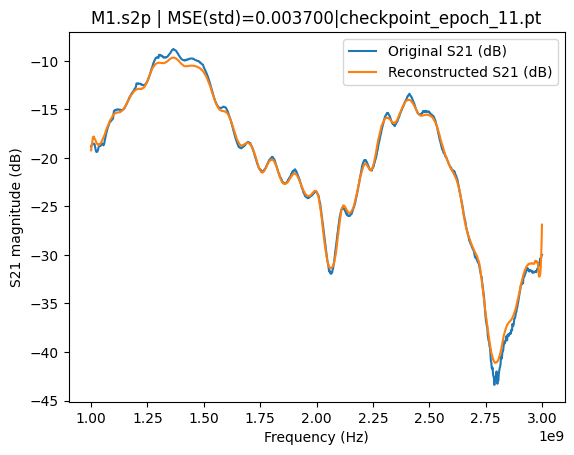

Test MSE (standardized space): 0.003700205823406577


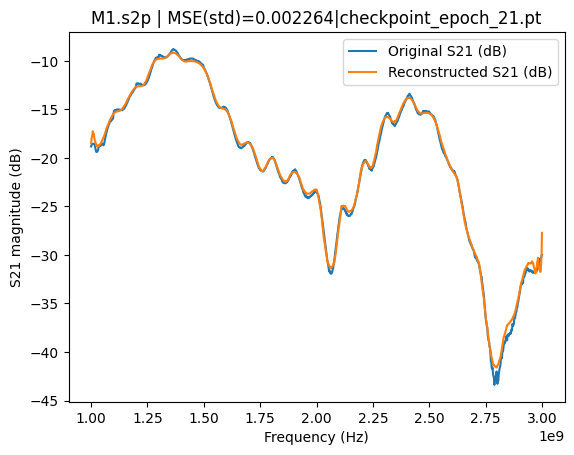

Test MSE (standardized space): 0.002263540169224143


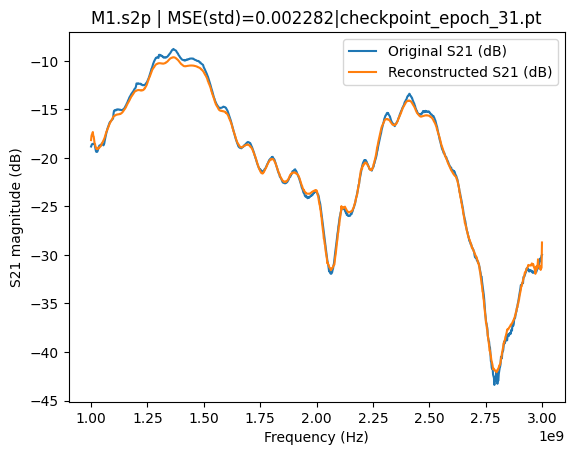

Test MSE (standardized space): 0.0022819419391453266


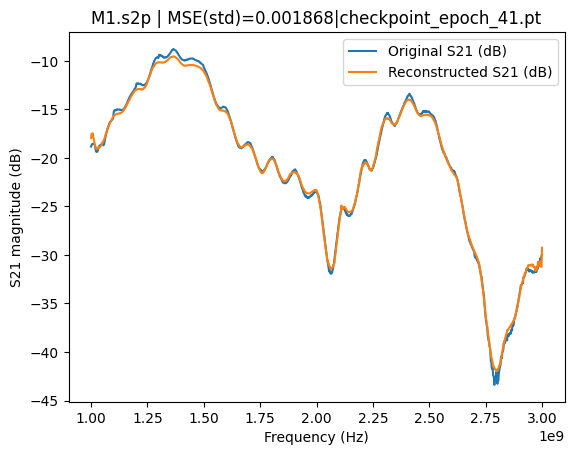

Test MSE (standardized space): 0.0018680039793252945


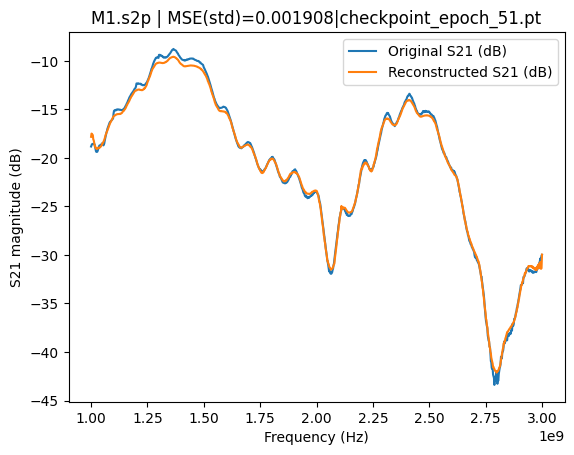

Test MSE (standardized space): 0.0019078310579061508


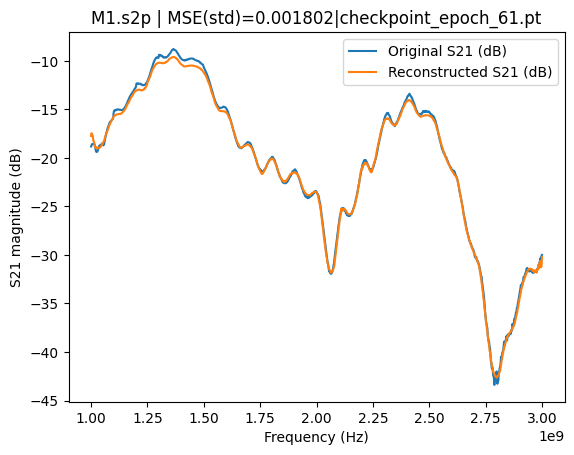

Test MSE (standardized space): 0.0018016493413597345


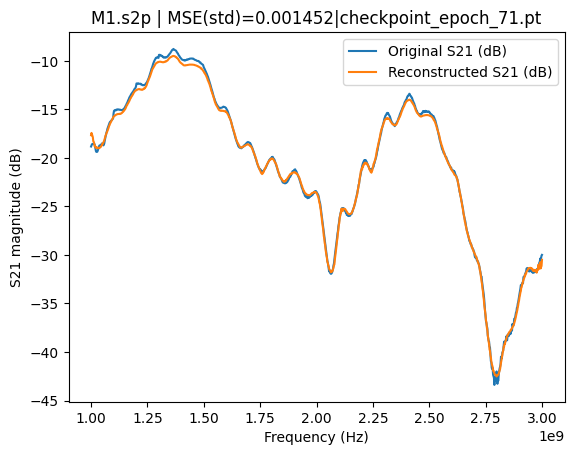

Test MSE (standardized space): 0.001451912336051464


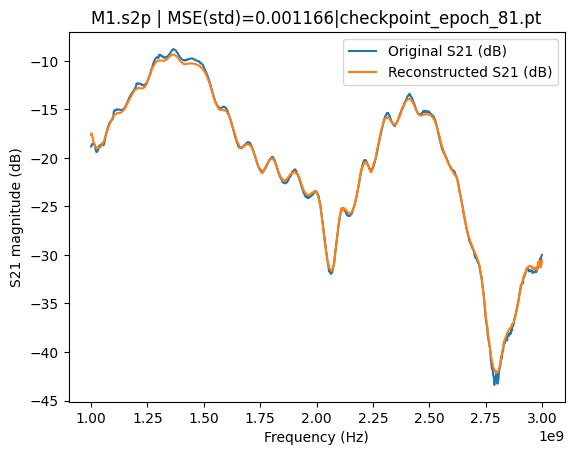

Test MSE (standardized space): 0.0011657730210572481


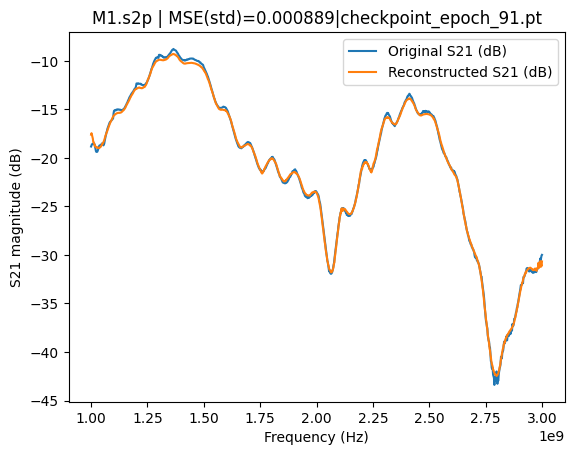

Test MSE (standardized space): 0.0008890565950423479


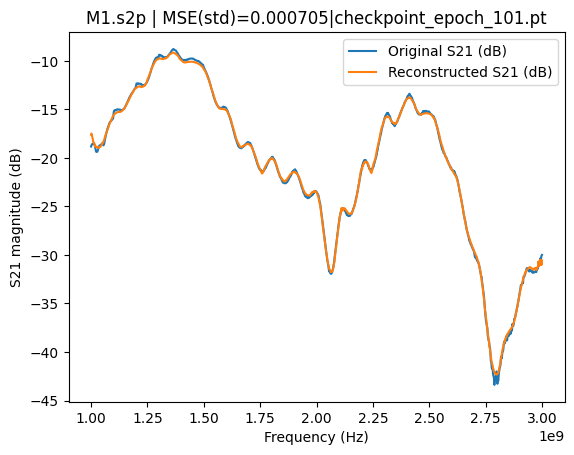

Test MSE (standardized space): 0.000705279060639441


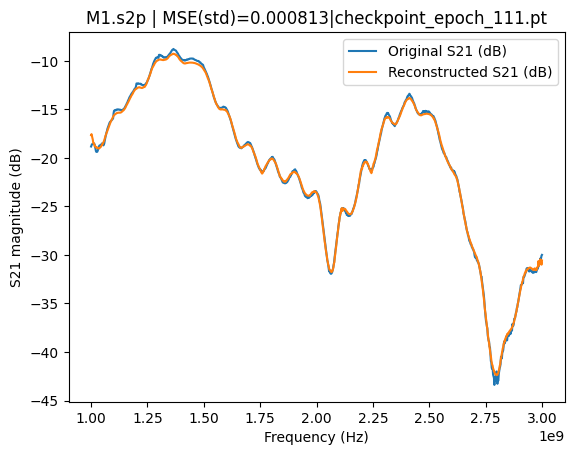

Test MSE (standardized space): 0.0008130756905302405


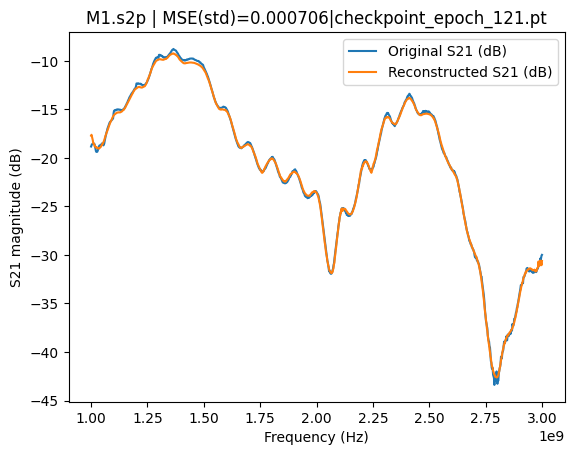

Test MSE (standardized space): 0.000705889193341136


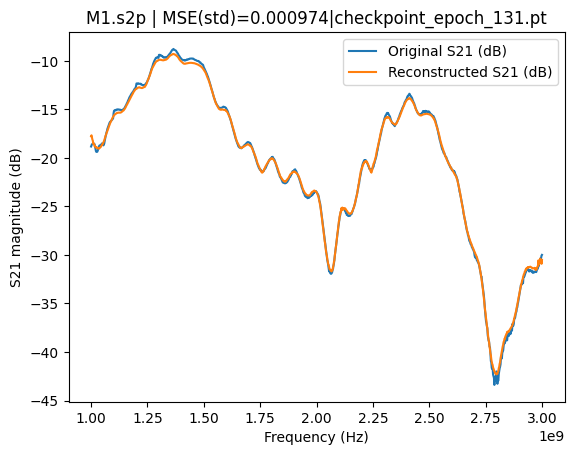

Test MSE (standardized space): 0.0009742254042066634


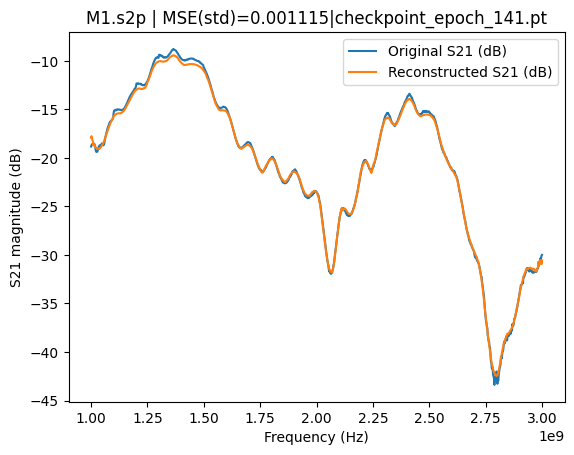

Test MSE (standardized space): 0.0011149736819788814


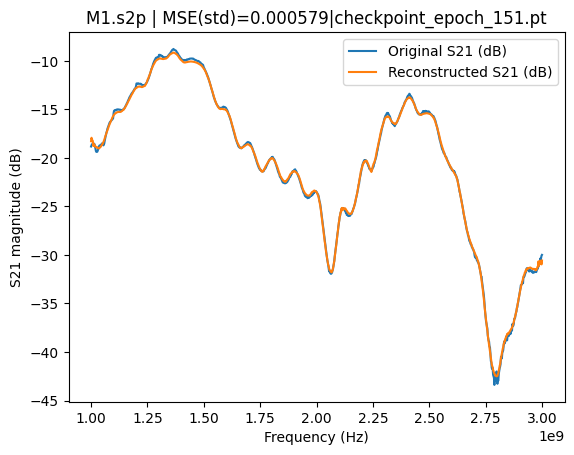

Test MSE (standardized space): 0.0005791111616417766


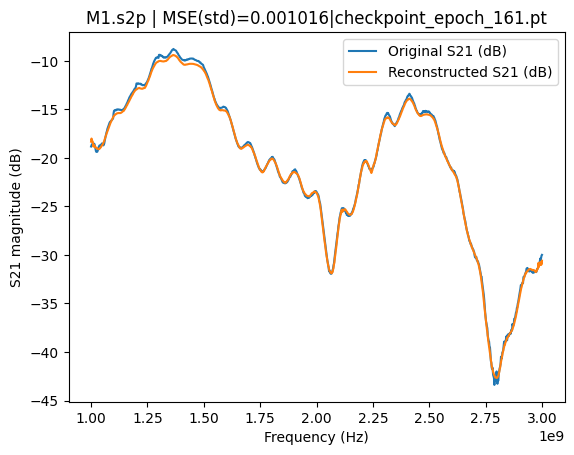

Test MSE (standardized space): 0.001016260706819594


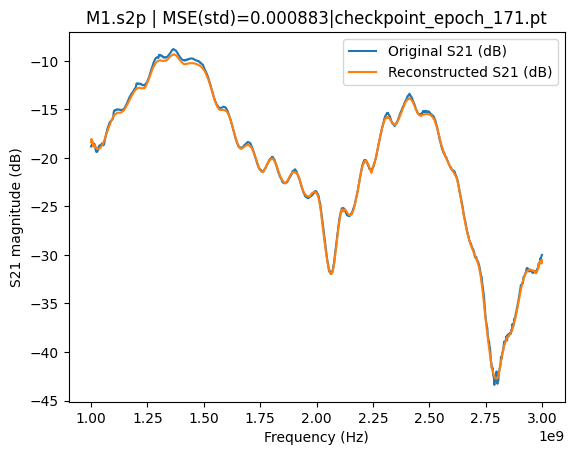

Test MSE (standardized space): 0.0008831965387798846


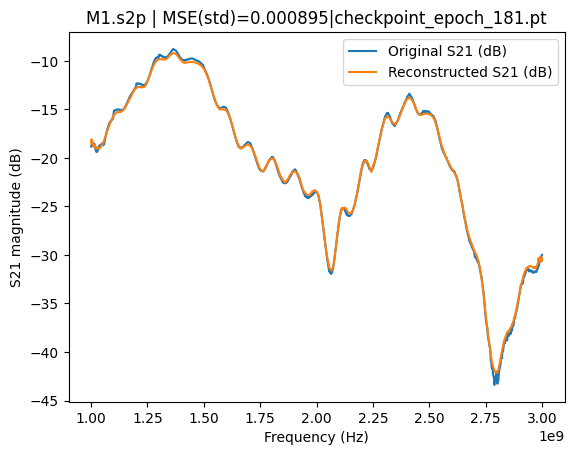

Test MSE (standardized space): 0.0008953363867476583


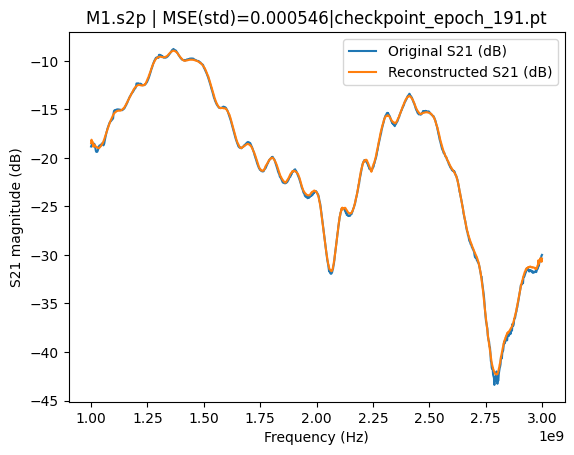

Test MSE (standardized space): 0.0005461401306092739


In [ ]:
checkpoint_path_root = "/content/drive/MyDrive/Data/checkpoints/de_autoencoder/combined/"
files = []
for file in os.listdir(checkpoint_path_root):
  if file.endswith(".pt"):
    files.append(file)

for file in files:
  checkpoint_path = checkpoint_path_root+file
  checkpoint = torch.load(checkpoint_path, map_location="cpu")

  model = Conv1DAutoencoder()
  model.load_state_dict(checkpoint["model_state_dict"])

  sample_path = "/content/drive/MyDrive/Data/MAS Volunteer Study March 2023/Volunteer 1/nanoVNA/Bandstop S1/M1.s2p"
  mse, (f, x_db, y_db) = test_one_file(model, sample_path,file)
  print("Test MSE (standardized space):", mse)

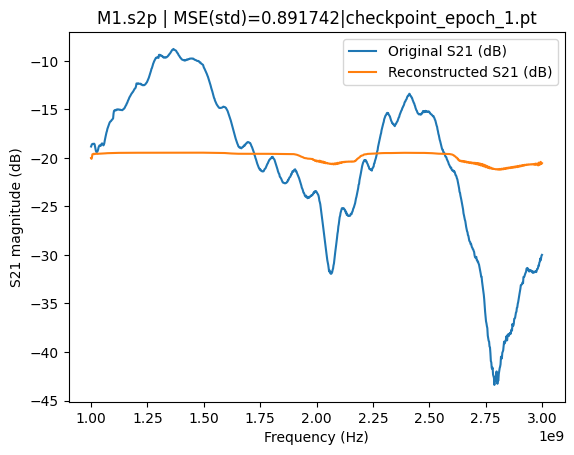

Test MSE (standardized space): 0.8917416930198669


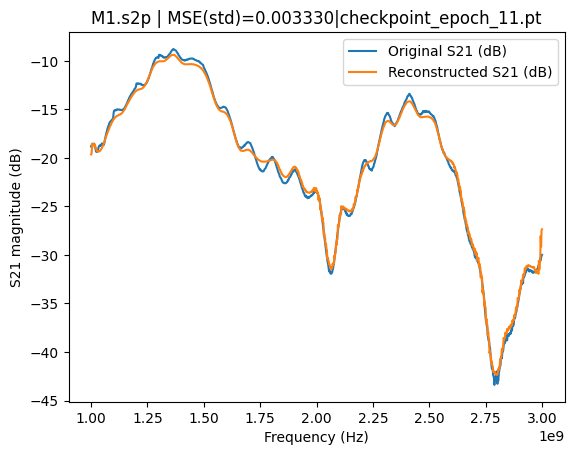

Test MSE (standardized space): 0.003329642117023468


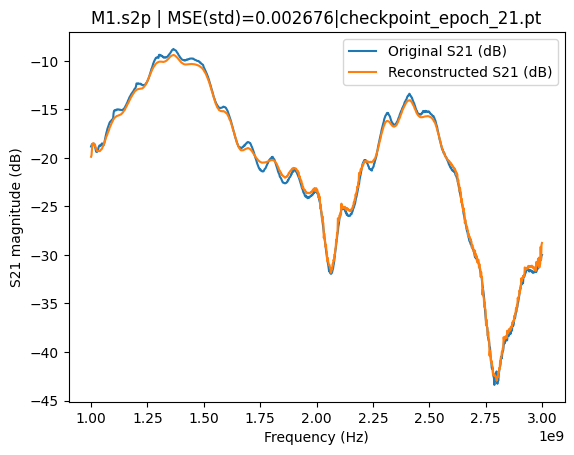

Test MSE (standardized space): 0.002676221542060375


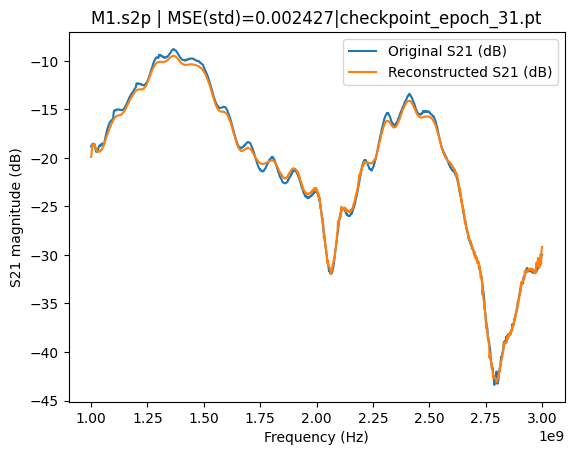

Test MSE (standardized space): 0.0024268620181828737


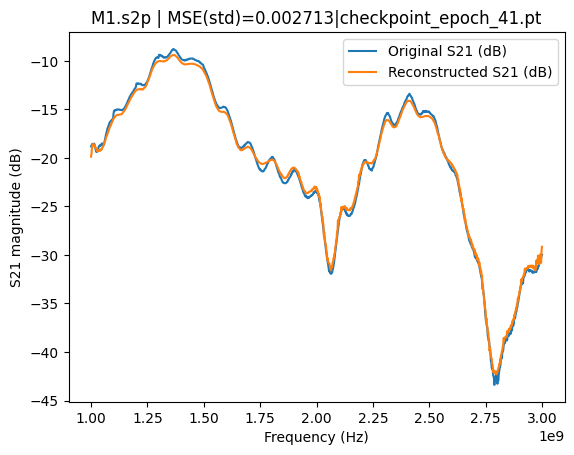

Test MSE (standardized space): 0.0027134278789162636


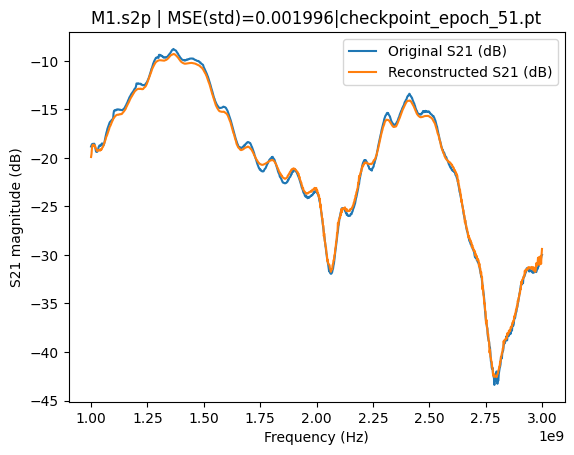

Test MSE (standardized space): 0.0019957118202000856


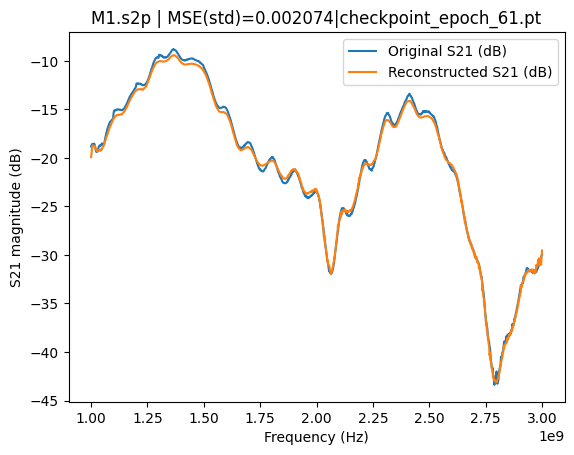

Test MSE (standardized space): 0.002073704730719328


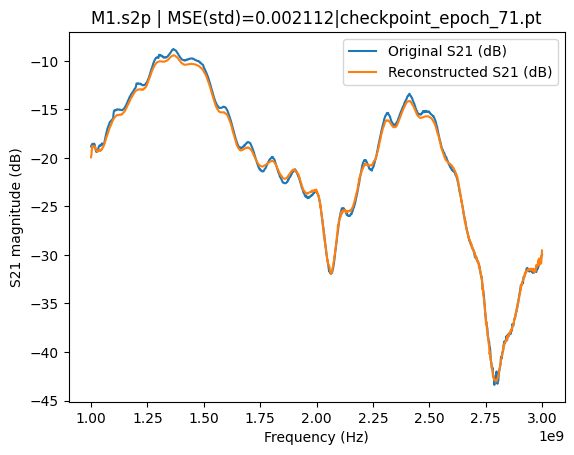

Test MSE (standardized space): 0.0021119010634720325


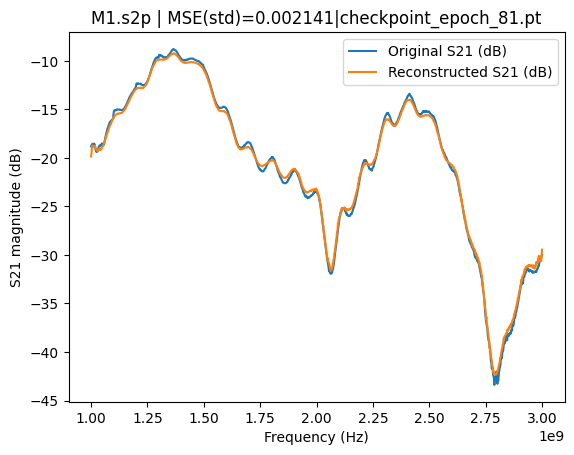

Test MSE (standardized space): 0.002141025383025408


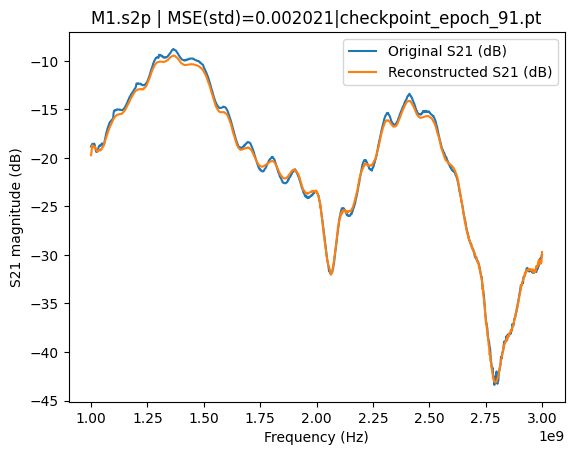

Test MSE (standardized space): 0.002020672196522355


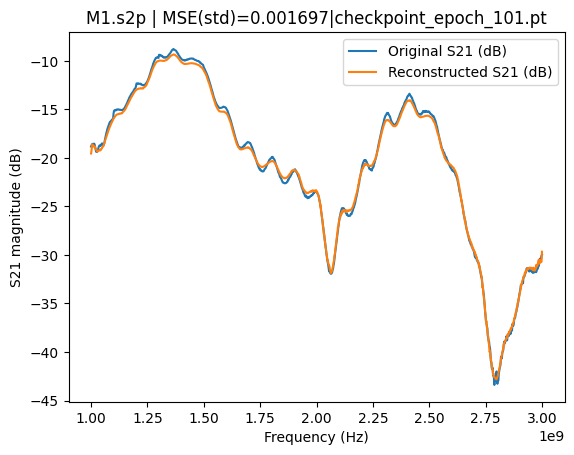

Test MSE (standardized space): 0.0016966400435194373


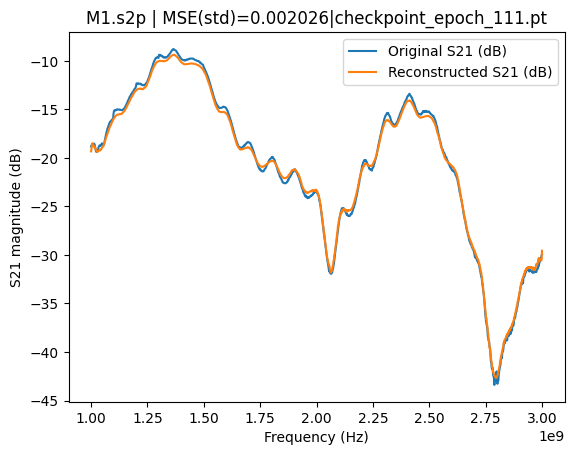

Test MSE (standardized space): 0.0020260706078261137


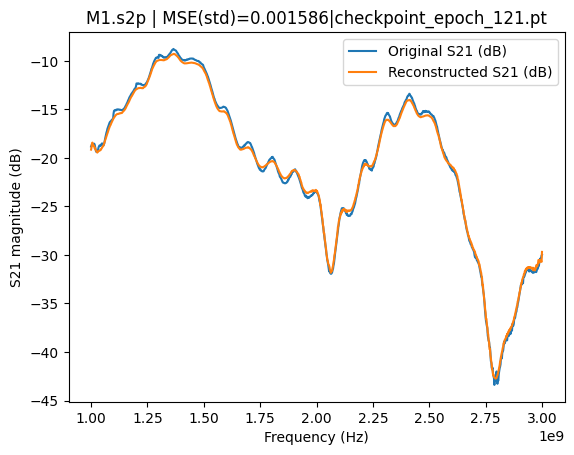

Test MSE (standardized space): 0.0015864339657127857


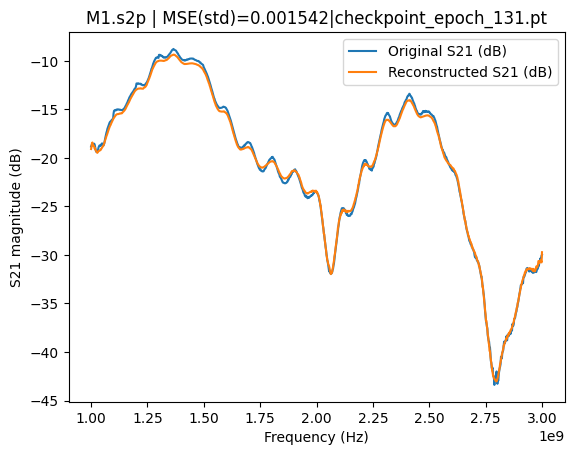

Test MSE (standardized space): 0.0015415141824632883


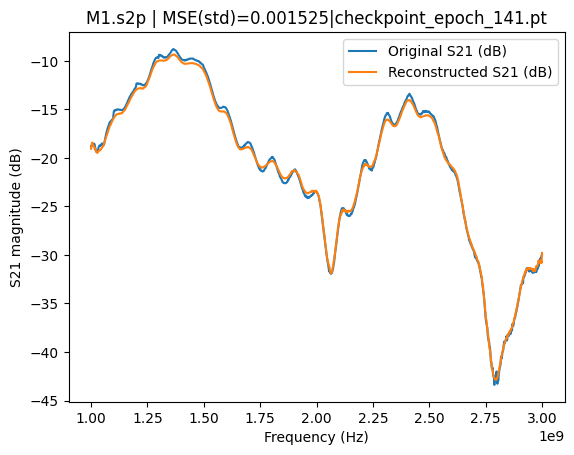

Test MSE (standardized space): 0.0015246266266331077


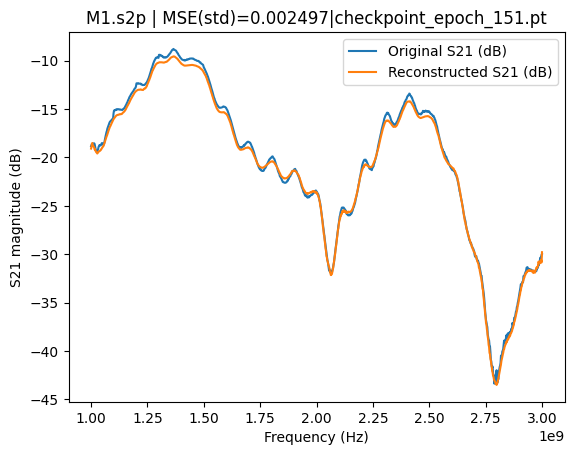

Test MSE (standardized space): 0.0024971964303404093


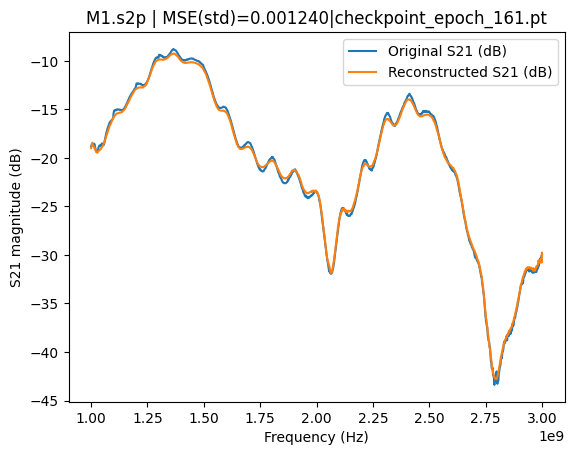

Test MSE (standardized space): 0.0012401040876284242


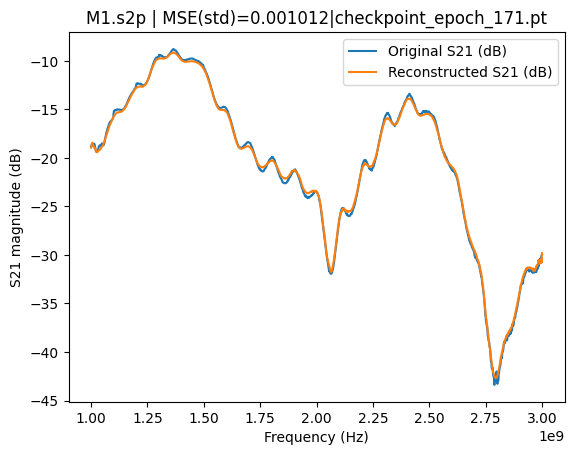

Test MSE (standardized space): 0.0010120586957782507


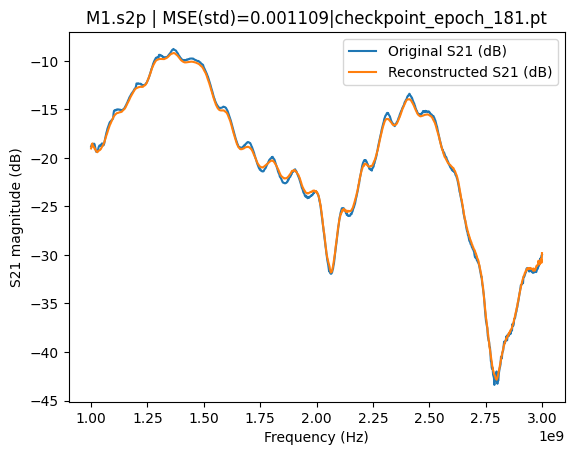

Test MSE (standardized space): 0.001109135104343295


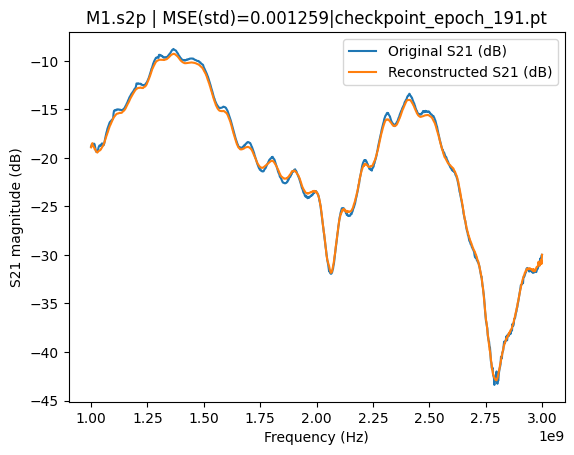

Test MSE (standardized space): 0.0012589282123371959


In [ ]:
checkpoint_path_root = "/content/drive/MyDrive/Data/checkpoints/de_autoencoder/gaussian/"
files = []
for file in os.listdir(checkpoint_path_root):
  if file.endswith(".pt"):
    files.append(file)

for file in files:
  checkpoint_path = checkpoint_path_root+file
  checkpoint = torch.load(checkpoint_path, map_location="cpu")

  model = Conv1DAutoencoder()
  model.load_state_dict(checkpoint["model_state_dict"])

  sample_path = "/content/drive/MyDrive/Data/MAS Volunteer Study March 2023/Volunteer 1/nanoVNA/Bandstop S1/M1.s2p"
  mse, (f, x_db, y_db) = test_one_file(model, sample_path,file)
  print("Test MSE (standardized space):", mse)

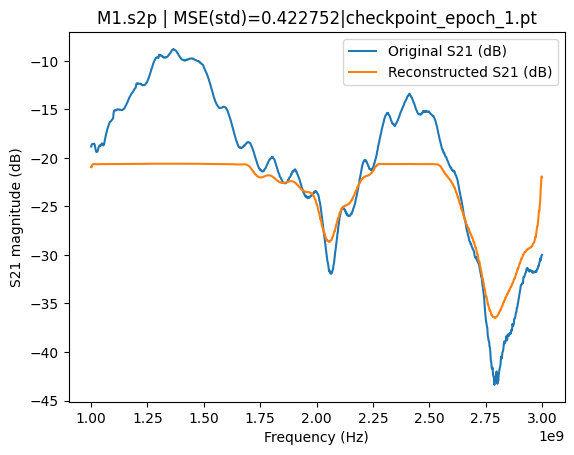

Test MSE (standardized space): 0.42275235056877136


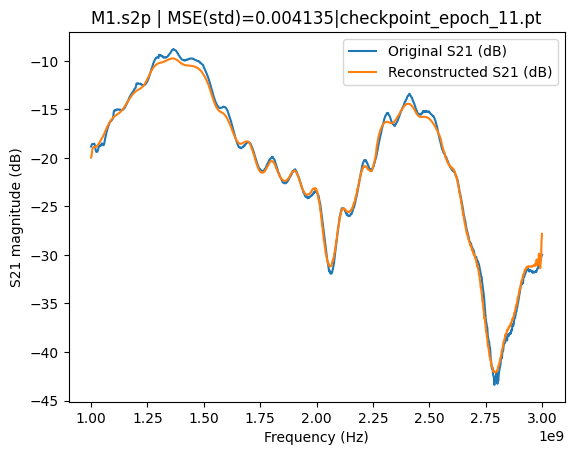

Test MSE (standardized space): 0.0041346438229084015


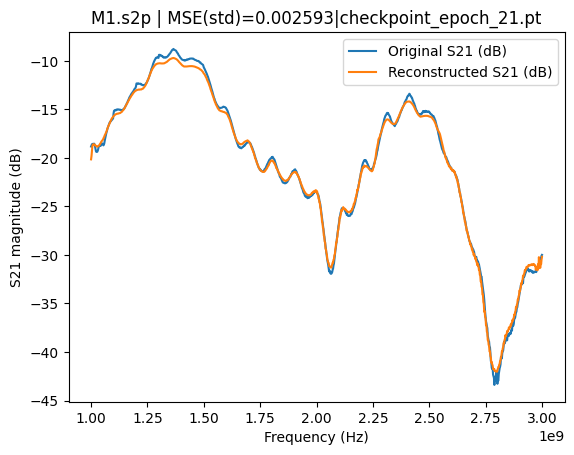

Test MSE (standardized space): 0.0025928039103746414


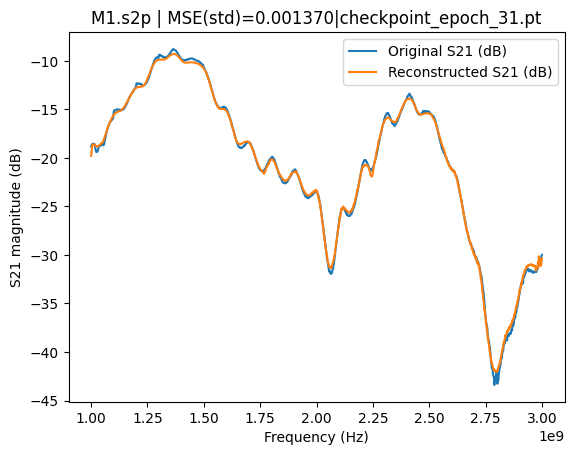

Test MSE (standardized space): 0.0013702891301363707


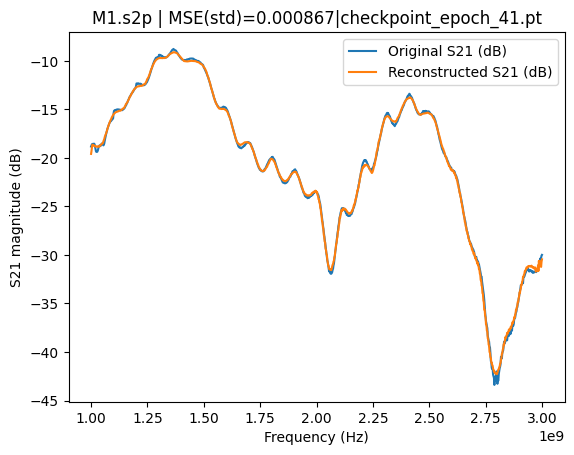

Test MSE (standardized space): 0.0008673924021422863


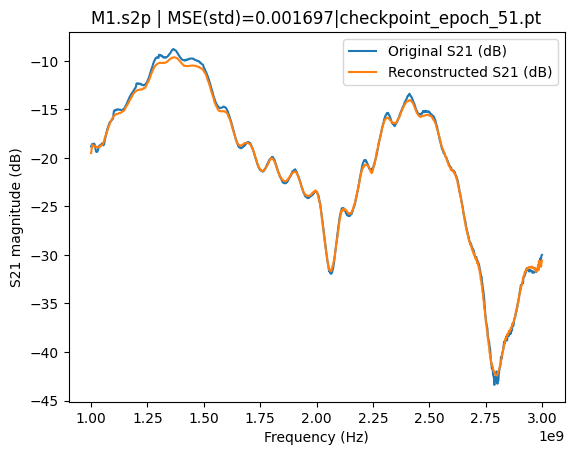

Test MSE (standardized space): 0.001697226078249514


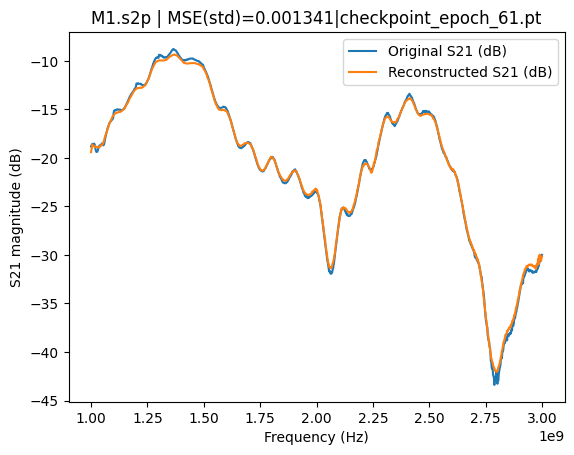

Test MSE (standardized space): 0.0013406993821263313


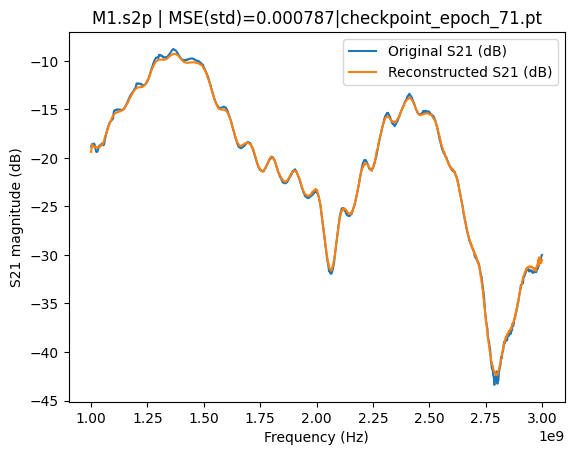

Test MSE (standardized space): 0.0007874673465266824


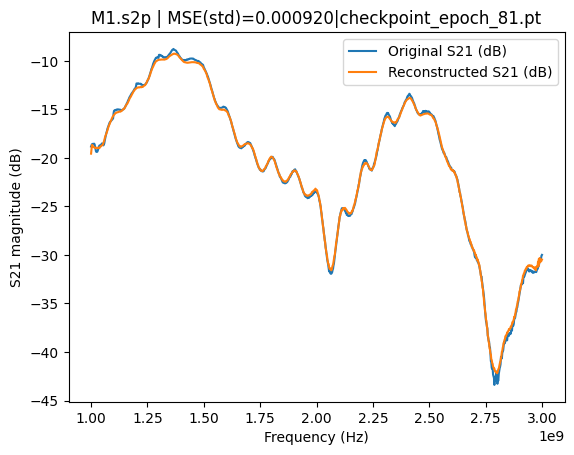

Test MSE (standardized space): 0.0009196230676025152


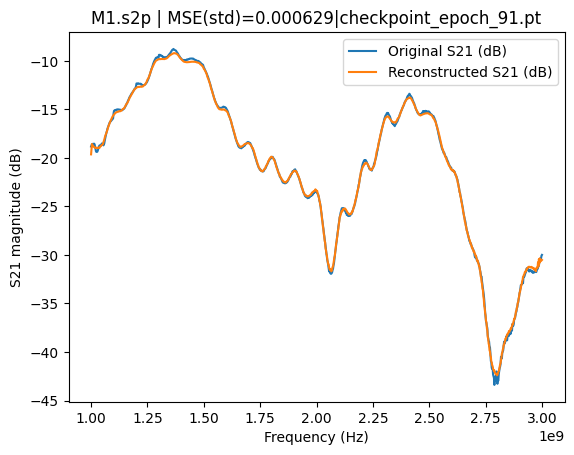

Test MSE (standardized space): 0.0006291423342190683


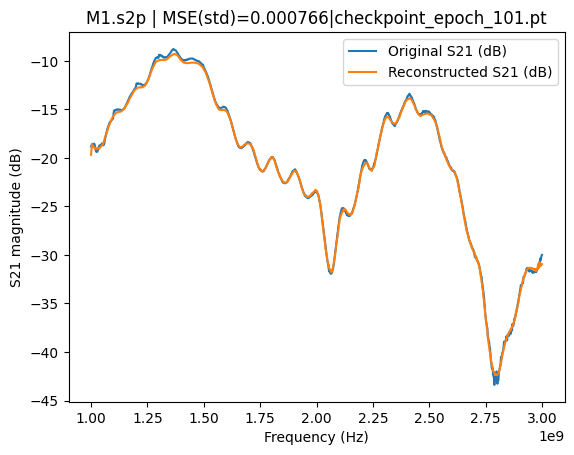

Test MSE (standardized space): 0.0007663973374292254


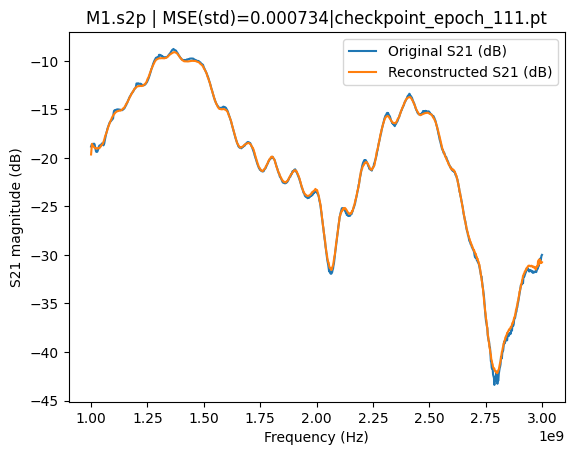

Test MSE (standardized space): 0.0007340541342273355


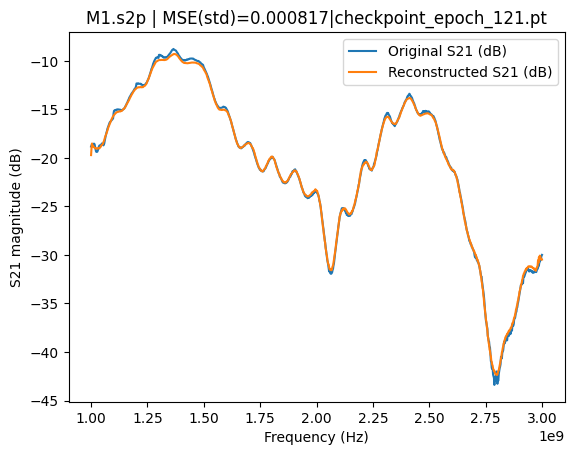

Test MSE (standardized space): 0.0008169157663360238


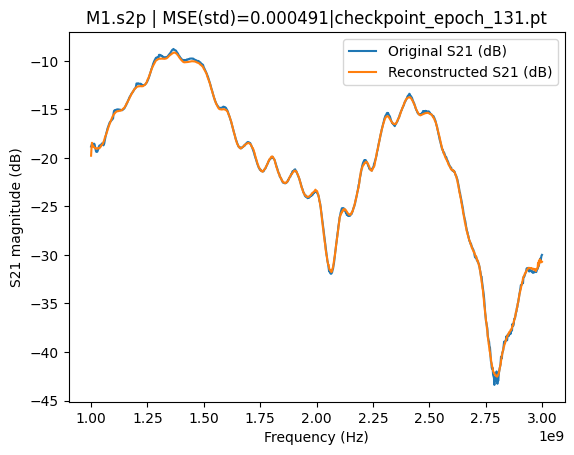

Test MSE (standardized space): 0.0004908583359792829


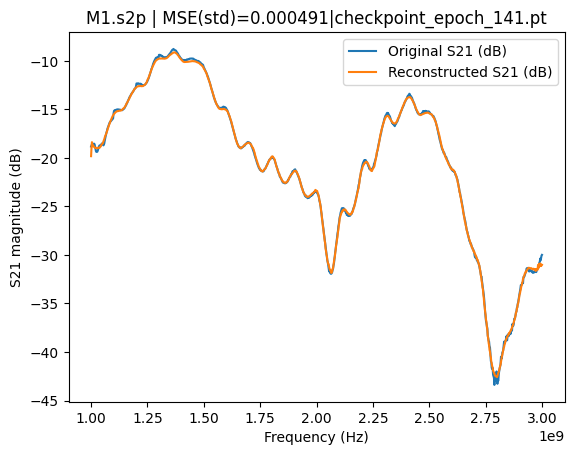

Test MSE (standardized space): 0.000490712292958051


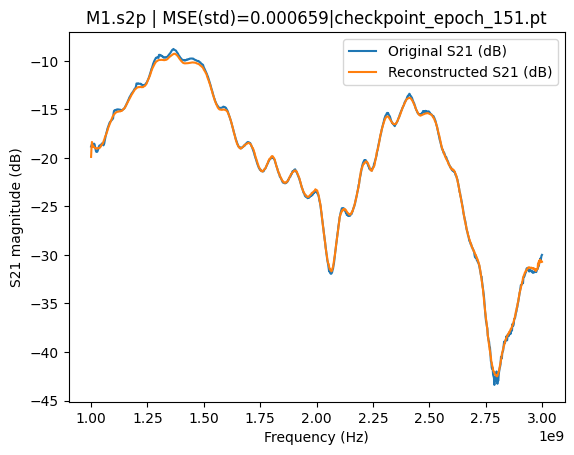

Test MSE (standardized space): 0.0006587433163076639


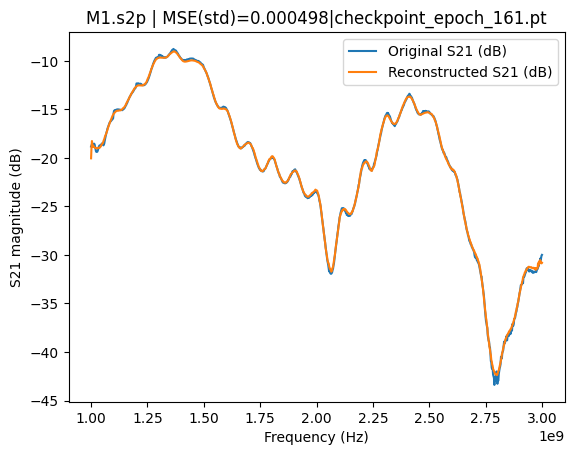

Test MSE (standardized space): 0.000497987843118608


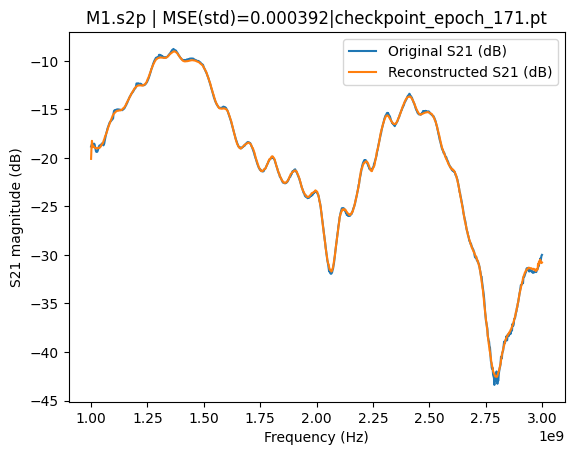

Test MSE (standardized space): 0.0003916398563887924


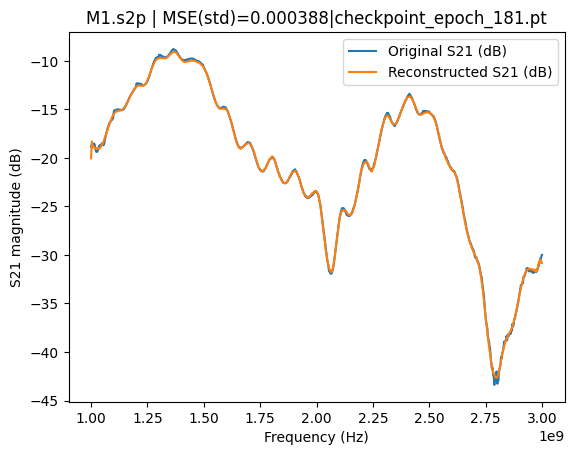

Test MSE (standardized space): 0.00038812647107988596


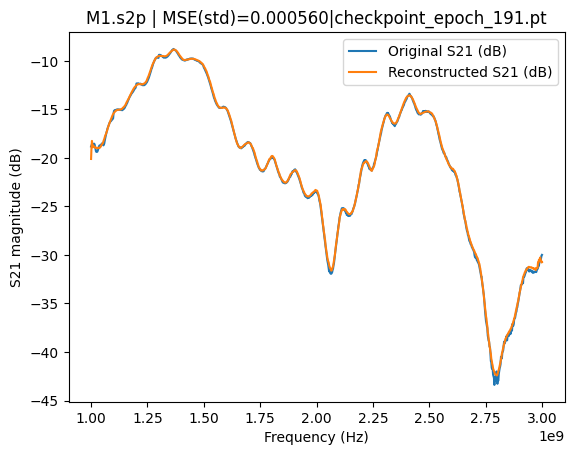

Test MSE (standardized space): 0.000559703097678721


In [ ]:
checkpoint_path_root = "/content/drive/MyDrive/Data/checkpoints/de_autoencoder/mask/"
files = []
for file in os.listdir(checkpoint_path_root):
  if file.endswith(".pt"):
    files.append(file)

for file in files:
  checkpoint_path = checkpoint_path_root+file
  checkpoint = torch.load(checkpoint_path, map_location="cpu")

  model = Conv1DAutoencoder()
  model.load_state_dict(checkpoint["model_state_dict"])

  sample_path = "/content/drive/MyDrive/Data/MAS Volunteer Study March 2022/Volunteer 1/nanoVNA/Bandstop S1/M1.s2p"
  mse, (f, x_db, y_db) = test_one_file(model, sample_path,file)
  print("Test MSE (standardized space):", mse)